# 06 — Selected Model Evaluation and Report Artifacts

Notebook này chạy sau khi đã chọn YOLOv8s và train extended ở notebook 05.

Vai trò:

- Không thay thế notebook 04.
- Không dùng để chọn model ban đầu.
- Dùng để **làm sạch số liệu cuối**, xuất chart/hình/bảng cho report và video demo.

Output chính:

- `experiments/yolo8s_ppe/metrics_extended_report_clean.json`
- `experiments/report_artifacts/selected_model/selected_model_overall_comparison.png`
- `experiments/report_artifacts/selected_model/selected_model_per_class_metrics.csv`
- `experiments/report_artifacts/selected_model/selected_model_per_class_map50.png`
- `experiments/report_artifacts/selected_model/selected_model_runtime_breakdown.png`
- `experiments/report_artifacts/selected_model/selected_model_detection_counts.png`
- `experiments/report_artifacts/selected_model/selected_model_risk_signal_preview.csv`
- `experiments/report_artifacts/selected_model/selected_model_report_artifacts.md`

Điểm quan trọng: runtime được tách rõ:

- `wall_time_fps`
- `wall_time_ms_per_image`
- `ultralytics_inference_ms_per_image`
- `ultralytics_preprocess_ms_per_image`
- `ultralytics_postprocess_ms_per_image`


## 0. Colab / Drive setup


In [1]:
from pathlib import Path
import os
import sys
import shutil

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    DRIVE_PROJECT = Path("/content/drive/MyDrive/factory-safety-ai-cctv")
    if not DRIVE_PROJECT.exists():
        raise FileNotFoundError(
            f"Không thấy project trên Drive: {DRIVE_PROJECT}\n"
            "Hãy chỉnh DRIVE_PROJECT cho đúng folder project của bạn."
        )
    PROJECT_ROOT = DRIVE_PROJECT.resolve()
else:
    PROJECT_ROOT = Path.cwd().resolve()

os.chdir(PROJECT_ROOT)
print("PROJECT_ROOT:", PROJECT_ROOT)


Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/factory-safety-ai-cctv


## 1. Install / imports


In [2]:
try:
    import ultralytics
except Exception:
    !pip install -q ultralytics pandas matplotlib pyyaml opencv-python pillow

from pathlib import Path
import json
import math
import time
from collections import defaultdict
from typing import Any

import pandas as pd
import matplotlib.pyplot as plt
import yaml
from PIL import Image
from IPython.display import display, Markdown

try:
    from ultralytics import YOLO
except Exception as exc:
    YOLO = None
    print("WARNING: Không import được YOLO:", exc)

try:
    import torch
    DEVICE = 0 if torch.cuda.is_available() else "cpu"
    print("CUDA:", torch.cuda.is_available())
    print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
except Exception:
    DEVICE = "cpu"
    print("Torch unavailable; using CPU fallback.")

print("DEVICE:", DEVICE)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA: True
GPU: Tesla T4
DEVICE: 0


## 2. Paths and configuration


In [3]:
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
YOLO8S_EXP_DIR = EXPERIMENTS_DIR / "yolo8s_ppe"
YOLO11S_EXP_DIR = EXPERIMENTS_DIR / "yolo11s_ppe"
PUBLIC_EXP_DIR = EXPERIMENTS_DIR / "public_ppe_baseline"

REPORT_DIR = EXPERIMENTS_DIR / "report_artifacts" / "selected_model"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

DATA_YAML = PROJECT_ROOT / "data/processed/ppe_yolo/data.yaml"
LOCAL_DATASET_ROOT = Path("/content/ppe_yolo_dataset")
LOCAL_DATA_YAML = LOCAL_DATASET_ROOT / "data.yaml"

CONF = 0.25
IMGSZ = 640
BATCH = 8
SAMPLE_LIMIT = 24

# Notebook 06 is mainly for report artifacts.
# Keep source-of-truth overall metrics from notebook 05 JSON to avoid unfair re-validation settings.
RUN_FRESH_VALIDATION = False
OVERWRITE_DATASET_METRICS_WITH_FRESH_VALIDATION = False

# If per-class metrics are missing from notebook 05 JSON, run a fresh validation only to recover per-class values.
# This does NOT overwrite the overall dataset_metrics used for model comparison/trade-off tables.
RUN_PER_CLASS_VALIDATION_IF_MISSING = True

RUN_SAMPLE_PREDICTION = True
SAVE_SELECTED_ALIAS = True        # Ghi thêm metrics_extended_selected.json để notebook/report khác đọc đúng run đã chọn.

PROJECT_CLASS_SCHEMA = {
    0: "person",
    1: "helmet",
    2: "head",
}

CLEAN_METRICS_PATH = YOLO8S_EXP_DIR / "metrics_extended_report_clean.json"
SELECTED_ALIAS_PATH = YOLO8S_EXP_DIR / "metrics_extended_selected.json"

print("DATA_YAML exists:", DATA_YAML.exists())
print("YOLO8S_EXP_DIR exists:", YOLO8S_EXP_DIR.exists())
print("REPORT_DIR:", REPORT_DIR)
print("RUN_FRESH_VALIDATION:", RUN_FRESH_VALIDATION)
print("RUN_PER_CLASS_VALIDATION_IF_MISSING:", RUN_PER_CLASS_VALIDATION_IF_MISSING)


DATA_YAML exists: True
YOLO8S_EXP_DIR exists: True
REPORT_DIR: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_model
RUN_FRESH_VALIDATION: False
RUN_PER_CLASS_VALIDATION_IF_MISSING: True


## 3. Helpers


In [4]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def read_json(path: Path, default=None):
    if default is None:
        default = {}
    if not path.exists():
        return default
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as exc:
        print(f"WARNING: cannot read JSON {path}: {exc}")
        return default

def write_json(path: Path, payload: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8")
    print("Saved:", path)

def safe_rel(path) -> str:
    if path is None:
        return "N/A"
    try:
        return str(Path(path).resolve().relative_to(PROJECT_ROOT))
    except Exception:
        return str(path)

def to_float_or_none(value: Any):
    if value is None:
        return None
    if isinstance(value, (int, float)):
        if isinstance(value, float) and math.isnan(value):
            return None
        return float(value)
    if isinstance(value, str):
        if value.strip().upper() in {"", "TBD", "N/A", "NA", "NONE", "NULL"}:
            return None
        try:
            return float(value)
        except Exception:
            return None
    return None

def fmt(value, digits=4):
    f = to_float_or_none(value)
    if f is None:
        return "N/A"
    return f"{f:.{digits}f}"

def collect_images_from_dir(root: Path, limit: int = 24):
    if not root.exists():
        return []
    return sorted([p for p in root.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS])[:limit]

def load_yaml_names(data_yaml: Path):
    if not data_yaml.exists():
        return {}
    try:
        data = yaml.safe_load(data_yaml.read_text(encoding="utf-8"))
        names = data.get("names", {})
        if isinstance(names, list):
            return {i: str(name) for i, name in enumerate(names)}
        if isinstance(names, dict):
            return {int(k): str(v) for k, v in names.items()}
    except Exception as exc:
        print("WARNING: cannot read yaml names:", exc)
    return {}

def copy_if_exists(src, dst):
    if src is None:
        return None
    src = Path(src)
    if not src.exists():
        return None
    dst = Path(dst)
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)
    print("Copied:", src, "->", dst)
    return dst

def show_image_grid(paths, title="Image grid", max_images=12, cols=3, figsize_per_image=(4, 3)):
    paths = [Path(p) for p in paths if Path(p).exists()]
    if not paths:
        print("No images to show for:", title)
        return

    paths = paths[:max_images]
    rows = math.ceil(len(paths) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per_image[0], rows * figsize_per_image[1]))
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = list(axes)
    else:
        axes = list(axes.flatten())

    for ax, path in zip(axes, paths):
        ax.imshow(Image.open(path).convert("RGB"))
        ax.set_title(path.name, fontsize=9)
        ax.axis("off")
    for ax in axes[len(paths):]:
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def average_result_speed(results) -> dict:
    speed_buckets = defaultdict(list)
    for result in results or []:
        speed = getattr(result, "speed", None)
        if not isinstance(speed, dict):
            continue
        for key, value in speed.items():
            try:
                speed_buckets[key].append(float(value))
            except Exception:
                pass
    return {
        f"ultralytics_{key}_ms_per_image": sum(values) / len(values)
        for key, values in speed_buckets.items()
        if values
    }

def class_name_from_id(active_model, class_id: int) -> str:
    names = getattr(active_model, "names", {}) if active_model is not None else {}
    if isinstance(names, dict):
        return str(names.get(class_id, class_id))
    if isinstance(names, list) and 0 <= class_id < len(names):
        return str(names[class_id])
    return PROJECT_CLASS_SCHEMA.get(class_id, str(class_id))

def map_class_to_project_signal(class_name: str) -> str:
    name = str(class_name).strip().lower().replace("_", "-")
    if name == "person":
        return "person_detected"
    if name in {"helmet", "hardhat", "safety helmet"}:
        return "helmet_detected"
    if name in {"head", "no-helmet", "no helmet", "no-hardhat", "no hardhat"}:
        return "head_or_no_helmet_detected"
    if "person" in name:
        return "person_detected"
    if "helmet" in name or "hardhat" in name:
        if name.startswith("no-") or "no " in name:
            return "head_or_no_helmet_detected"
        return "helmet_detected"
    if "head" in name:
        return "head_or_no_helmet_detected"
    return "not_used_in_mvp"


# ===== Plot/table formatting helpers for report-ready artifacts =====
import textwrap

def format_percent_label(value, digits=1):
    f = to_float_or_none(value)
    if f is None:
        return "N/A"
    return f"{f * 100:.{digits}f}%"

def format_score_bar_label(value, digits=1):
    f = to_float_or_none(value)
    if f is None:
        return ""
    # Most validation scores are stored in [0, 1].
    return f"{f * 100:.{digits}f}%" if abs(f) <= 1.2 else f"{f:.{digits}f}"

def format_fps_label(value, digits=1):
    f = to_float_or_none(value)
    return "" if f is None else f"{f:.{digits}f}"

def format_ms_label(value, digits=2):
    f = to_float_or_none(value)
    return "" if f is None else f"{f:.{digits}f} ms"

def format_count_label(value):
    f = to_float_or_none(value)
    return "" if f is None else f"{f:.0f}"

def format_delta_pp_label(value, digits=2):
    f = to_float_or_none(value)
    return "" if f is None else f"{f:+.{digits}f} pp"

def annotate_bars(ax, formatter=None, fontsize=8, rotation=0, y_pad_ratio=0.015):
    """Add value labels on top of all vertical bar containers in an axis."""
    if formatter is None:
        formatter = lambda v: f"{v:.2f}"

    ymin, ymax = ax.get_ylim()
    y_range = ymax - ymin if ymax != ymin else 1
    pad = y_range * y_pad_ratio

    heights = []
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            try:
                if height is None or math.isnan(float(height)):
                    continue
            except Exception:
                continue
            heights.append(height)
            label = formatter(height)
            if not label:
                continue
            x = bar.get_x() + bar.get_width() / 2
            if height >= 0:
                y = height + pad
                va = "bottom"
            else:
                y = height - pad
                va = "top"
            ax.text(x, y, label, ha="center", va=va, fontsize=fontsize, rotation=rotation)

    if heights:
        positive = [h for h in heights if h >= 0]
        negative = [h for h in heights if h < 0]
        if positive:
            max_h = max(positive)
            ax.set_ylim(top=max(ax.get_ylim()[1], max_h * 1.18 if max_h > 0 else ax.get_ylim()[1]))
        if negative:
            min_h = min(negative)
            ax.set_ylim(bottom=min(ax.get_ylim()[0], min_h * 1.18))

def wrap_cell_text(value, width=24):
    if value is None:
        return ""
    text = str(value)
    if text.lower() == "nan":
        return ""
    if len(text) <= width:
        return text
    return "\n".join(textwrap.wrap(text, width=width, break_long_words=False))


## 4. Copy processed dataset to local runtime


In [5]:
# Validation/prediction chạy nhanh hơn nếu copy dataset sang /content.
if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"Missing processed dataset YAML: {DATA_YAML}\n"
        "Hãy kiểm tra lại data/processed/ppe_yolo/data.yaml."
    )

if IN_COLAB:
    if LOCAL_DATASET_ROOT.exists():
        shutil.rmtree(LOCAL_DATASET_ROOT)
    shutil.copytree(DATA_YAML.parent, LOCAL_DATASET_ROOT)
    ACTIVE_DATA_YAML = LOCAL_DATA_YAML
else:
    ACTIVE_DATA_YAML = DATA_YAML

print("ACTIVE_DATA_YAML:", ACTIVE_DATA_YAML)
print("Dataset names:", load_yaml_names(ACTIVE_DATA_YAML))


ACTIVE_DATA_YAML: /content/ppe_yolo_dataset/data.yaml
Dataset names: {0: 'person', 1: 'helmet', 2: 'head'}


## 5. Select extended metrics run and checkpoint

This notebook treats selection at two levels:

1. **Selected extended run**: among all `metrics_50ep_extended_*.json` files, select the run with the best validation metric, prioritizing `mAP50_95`, then `mAP50`, then `recall`.
2. **Best checkpoint inside that selected run**: use the run's `weights/best.pt`, not `last.pt`.

If you only trained extended once, the selected extended run is simply that single run. The word **selected** is used here to avoid confusion with `last.pt` or timestamp-based file naming.


In [6]:
BEST_RUN_SELECTION_METRICS = ["mAP50_95", "mAP50", "recall", "precision"]

def _metric_sort_value(value):
    value = to_float_or_none(value)
    return value if value is not None else float("-inf")

def score_metrics_payload(payload: dict) -> tuple:
    dataset_metrics = payload.get("dataset_metrics", {}) if isinstance(payload, dict) else {}
    return tuple(_metric_sort_value(dataset_metrics.get(name)) for name in BEST_RUN_SELECTION_METRICS)

def collect_extended_metric_files():
    """Collect extended metrics files.

    Prefer timestamped files because their filename usually maps to the matching
    training run folder, e.g. metrics_50ep_extended_YYYYMMDD_HHMMSS.json.
    The selected alias is only a fallback for older/manual runs.
    """
    timestamped = sorted(YOLO8S_EXP_DIR.glob("metrics_50ep_extended_*.json"))
    if timestamped:
        return timestamped

    # Fallback for older/manual files.
    candidates = []
    if SELECTED_ALIAS_PATH.exists():
        candidates.append(SELECTED_ALIAS_PATH)
    candidates.extend(sorted(YOLO8S_EXP_DIR.glob("metrics_*extended*.json")))

    seen = set()
    unique = []
    for path in candidates:
        if path.exists() and path not in seen:
            unique.append(path)
            seen.add(path)
    return unique

def select_best_extended_metrics():
    candidates = collect_extended_metric_files()
    rows = []

    for path in candidates:
        payload = read_json(path, default={})
        score = score_metrics_payload(payload)
        rows.append({
            "path": path,
            "payload": payload,
            "score": score,
            "mAP50_95": payload.get("dataset_metrics", {}).get("mAP50_95", None),
            "mAP50": payload.get("dataset_metrics", {}).get("mAP50", None),
            "recall": payload.get("dataset_metrics", {}).get("recall", None),
            "precision": payload.get("dataset_metrics", {}).get("precision", None),
            "modified_time": path.stat().st_mtime,
        })

    if not rows:
        return None, None, pd.DataFrame()

    # Choose best validation score; use modified time only as tie-breaker.
    rows_sorted = sorted(rows, key=lambda r: (r["score"], r["modified_time"]), reverse=True)
    selected = rows_sorted[0]

    table = pd.DataFrame([
        {
            "selected": "YES" if row is selected else "",
            "metrics_file": safe_rel(row["path"]),
            "mAP50_95": row["mAP50_95"],
            "mAP50": row["mAP50"],
            "recall": row["recall"],
            "precision": row["precision"],
        }
        for row in rows_sorted
    ])
    return selected["path"], selected["payload"], table

def resolve_path_from_metrics(metrics: dict, *keys):
    current = metrics
    for key in keys:
        if not isinstance(current, dict):
            return None
        current = current.get(key)
    if not current or str(current).upper() in {"TBD", "N/A", "NONE", "NULL", ""}:
        return None
    p = Path(str(current))
    if not p.is_absolute():
        p = PROJECT_ROOT / p
    return p

def infer_timestamp_from_metrics_path(metrics_path: Path):
    # Example: metrics_50ep_extended_20260708_173557.json -> 20260708_173557
    stem = metrics_path.stem
    marker = "extended_"
    if marker not in stem:
        return None
    return stem.split(marker, 1)[-1]

def find_best_checkpoint_for_selected_run(metrics: dict, metrics_path: Path):
    candidates = []

    # First priority: explicit path stored in metrics JSON.
    for keys in [
        ("artifacts", "best_pt"),
        ("artifacts", "best_checkpoint"),
        ("selected_checkpoint",),
        ("best_pt",),
        ("checkpoint",),
        ("model_path",),
    ]:
        p = resolve_path_from_metrics(metrics, *keys)
        if p:
            candidates.append(p)

    # Second priority: train_dir in metrics JSON.
    train_dir = resolve_path_from_metrics(metrics, "artifacts", "train_dir")
    if train_dir:
        candidates.append(train_dir / "weights" / "best.pt")

    # Third priority: infer from timestamp in metrics filename.
    stamp = infer_timestamp_from_metrics_path(metrics_path)
    if stamp:
        candidates.extend(sorted(YOLO8S_EXP_DIR.glob(f"runs/train_*selected_{stamp}/weights/best.pt")))
        candidates.extend(sorted(YOLO8S_EXP_DIR.glob(f"runs/train_*{stamp}*/weights/best.pt")))

    existing = [p for p in candidates if p.exists()]
    if existing:
        return existing[0]

    # Last-resort fallback. This is intentionally not the primary behavior.
    fallback = sorted(YOLO8S_EXP_DIR.glob("runs/train_*selected*/weights/best.pt"))
    if fallback:
        print("WARNING: Could not map metrics file to its exact checkpoint. Falling back to newest selected best.pt.")
        return sorted(fallback, key=lambda p: p.stat().st_mtime)[-1]

    fallback = sorted(YOLO8S_EXP_DIR.glob("runs/**/weights/best.pt"))
    if fallback:
        print("WARNING: Could not map metrics file to its exact checkpoint. Falling back to newest available best.pt.")
        return sorted(fallback, key=lambda p: p.stat().st_mtime)[-1]

    return None

EXTENDED_METRICS_SOURCE, metrics_payload, EXTENDED_RUN_TABLE = select_best_extended_metrics()
if EXTENDED_METRICS_SOURCE is None:
    raise FileNotFoundError(
        "Không tìm thấy metrics extended. Hãy chạy notebook 05 trước.\n"
        "Expected examples: experiments/yolo8s_ppe/metrics_50ep_extended_*.json"
    )

BEST_PT = find_best_checkpoint_for_selected_run(metrics_payload, EXTENDED_METRICS_SOURCE)

print("Selected extended metrics by best validation score:", EXTENDED_METRICS_SOURCE)
print("Selection priority:", " > ".join(BEST_RUN_SELECTION_METRICS))
print("BEST_PT:", BEST_PT)

if not EXTENDED_RUN_TABLE.empty:
    display(EXTENDED_RUN_TABLE)

if BEST_PT is None:
    raise FileNotFoundError(
        "Không tìm thấy best.pt tương ứng với selected extended run.\n"
        "Hãy kiểm tra artifacts.best_pt trong metrics JSON hoặc folder runs/train_*selected*/weights/best.pt"
    )

display(pd.DataFrame([{
    "metrics_source": safe_rel(EXTENDED_METRICS_SOURCE),
    "best_pt": safe_rel(BEST_PT),
    "status": metrics_payload.get("status", "TBD"),
    "mAP50": metrics_payload.get("dataset_metrics", {}).get("mAP50", "TBD"),
    "mAP50_95": metrics_payload.get("dataset_metrics", {}).get("mAP50_95", "TBD"),
    "precision": metrics_payload.get("dataset_metrics", {}).get("precision", "TBD"),
    "recall": metrics_payload.get("dataset_metrics", {}).get("recall", "TBD"),
}]))



Selected extended metrics by best validation score: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/yolo8s_ppe/metrics_50ep_extended_20260708_173557.json
Selection priority: mAP50_95 > mAP50 > recall > precision
BEST_PT: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/yolo8s_ppe/runs/train_50ep_selected_20260708_173557/weights/best.pt


,selected,metrics_file,mAP50_95,mAP50,recall,precision
0,YES,experiments/yolo8s_ppe/metrics_50ep_extended_2...,0.449971,0.658625,0.621641,0.960962


,metrics_source,best_pt,status,mAP50,mAP50_95,precision,recall
0,experiments/yolo8s_ppe/metrics_50ep_extended_2...,experiments/yolo8s_ppe/runs/train_50ep_selecte...,trained_or_validated,0.658625,0.449971,0.960962,0.621641


## 6. Clean runtime fields from existing metrics


In [7]:
def clean_runtime_metrics(runtime_metrics: dict) -> dict:
    rt = dict(runtime_metrics or {})

    # Backward compatibility với notebook 05 cũ:
    # avg_inference_ms_per_image có thể đang là wall-time hoặc bị overwrite bởi Ultralytics inference-only.
    cleaned = {}

    if "wall_time_fps" in rt:
        cleaned["wall_time_fps"] = rt.get("wall_time_fps")
    elif "fps_estimate" in rt:
        cleaned["wall_time_fps"] = rt.get("fps_estimate")

    if "wall_time_ms_per_image" in rt:
        cleaned["wall_time_ms_per_image"] = rt.get("wall_time_ms_per_image")
    elif to_float_or_none(cleaned.get("wall_time_fps")):
        cleaned["wall_time_ms_per_image"] = 1000.0 / float(cleaned["wall_time_fps"])

    # Ultralytics keys may exist as avg_preprocess / avg_inference / avg_postprocess.
    if "ultralytics_preprocess_ms_per_image" in rt:
        cleaned["ultralytics_preprocess_ms_per_image"] = rt.get("ultralytics_preprocess_ms_per_image")
    elif "avg_preprocess_ms_per_image" in rt:
        cleaned["ultralytics_preprocess_ms_per_image"] = rt.get("avg_preprocess_ms_per_image")

    if "ultralytics_inference_ms_per_image" in rt:
        cleaned["ultralytics_inference_ms_per_image"] = rt.get("ultralytics_inference_ms_per_image")
    elif "avg_inference_ms_per_image" in rt:
        # In old files this may be ambiguous. If fps exists, treat avg_inference as Ultralytics inference-only.
        cleaned["ultralytics_inference_ms_per_image"] = rt.get("avg_inference_ms_per_image")

    if "ultralytics_postprocess_ms_per_image" in rt:
        cleaned["ultralytics_postprocess_ms_per_image"] = rt.get("ultralytics_postprocess_ms_per_image")
    elif "avg_postprocess_ms_per_image" in rt:
        cleaned["ultralytics_postprocess_ms_per_image"] = rt.get("avg_postprocess_ms_per_image")

    cleaned["benchmark_type"] = rt.get("benchmark_type", "TBD")
    cleaned["runtime_cleaning_note"] = (
        "wall_time_* fields are end-to-end predict(save=False) timing; "
        "ultralytics_* fields are internal Ultralytics speed breakdown."
    )

    return cleaned

metrics_payload["runtime_metrics"] = clean_runtime_metrics(metrics_payload.get("runtime_metrics", {}))
display(pd.DataFrame([metrics_payload["runtime_metrics"]]))


,wall_time_fps,wall_time_ms_per_image,ultralytics_preprocess_ms_per_image,ultralytics_inference_ms_per_image,ultralytics_postprocess_ms_per_image,benchmark_type,runtime_cleaning_note
0,69.069378,14.478196,1.891813,8.750117,0.766388,clean_predict_save_false_wall_time,wall_time_* fields are end-to-end predict(save...


## 7. Load selected model and run fresh validation


In [8]:
selected_model = None
model_load_error = None

if YOLO is None:
    model_load_error = "Ultralytics YOLO is not available."
else:
    try:
        selected_model = YOLO(str(BEST_PT))
        print("Loaded selected model:", BEST_PT)
        print("Model names:", getattr(selected_model, "names", {}))
    except Exception as exc:
        model_load_error = str(exc)
        print("Cannot load selected model:", model_load_error)

val_metrics = None
val_error = None

# IMPORTANT:
# Notebook 06 should not accidentally replace the source-of-truth metrics from notebook 05.
# If fresh validation is requested, keep it in metrics_payload['fresh_validation_metrics'] by default.
if RUN_FRESH_VALIDATION and selected_model is not None:
    try:
        val_metrics = selected_model.val(
            data=str(ACTIVE_DATA_YAML),
            imgsz=IMGSZ,
            batch=BATCH,
            # Do not pass conf=CONF here. Leave Ultralytics validation defaults for fair metric reporting.
            device=DEVICE,
            project=str(YOLO8S_EXP_DIR / "runs"),
            name="val_selected_report_artifacts",
            exist_ok=True,
        )
        print("Fresh validation done.")
    except Exception as exc:
        val_error = str(exc)
        print("Fresh validation failed:", val_error)
else:
    print("Fresh validation skipped. Using notebook 05 JSON as source-of-truth for overall metrics.")

def metric_value(metrics, attr_path: str):
    if metrics is None:
        return None
    current = metrics
    for part in attr_path.split("."):
        if current is None:
            return None
        current = getattr(current, part, None)
    try:
        return float(current)
    except Exception:
        return current

if val_metrics is not None:
    fresh_validation_metrics = {
        "mAP50": metric_value(val_metrics, "box.map50"),
        "mAP50_95": metric_value(val_metrics, "box.map"),
        "precision": metric_value(val_metrics, "box.mp"),
        "recall": metric_value(val_metrics, "box.mr"),
    }
    metrics_payload["fresh_validation_metrics"] = fresh_validation_metrics
    if OVERWRITE_DATASET_METRICS_WITH_FRESH_VALIDATION:
        metrics_payload["dataset_metrics"] = fresh_validation_metrics
        print("WARNING: dataset_metrics was overwritten with fresh validation metrics.")
    else:
        print("Fresh validation metrics stored separately and did not overwrite dataset_metrics.")

metrics_payload.setdefault("errors", {})
metrics_payload["errors"]["report_validation_error"] = val_error
metrics_payload["errors"]["report_model_load_error"] = model_load_error

display(pd.DataFrame([metrics_payload.get("dataset_metrics", {})]))


Loaded selected model: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/yolo8s_ppe/runs/train_50ep_selected_20260708_173557/weights/best.pt
Model names: {0: 'person', 1: 'helmet', 2: 'head'}
Fresh validation skipped. Using notebook 05 JSON as source-of-truth for overall metrics.


,mAP50,mAP50_95,precision,recall
0,0.658625,0.449971,0.960962,0.621641


## 8. Extract per-class metrics


In [9]:
def get_array_attr(obj, attr_names):
    for attr in attr_names:
        value = getattr(obj, attr, None)
        if value is not None:
            try:
                return list(value)
            except Exception:
                pass
    return None

def _saved_per_class_lookup(saved_pc, class_id, class_name):
    if not isinstance(saved_pc, dict):
        return {}
    candidates = [class_name, str(class_name), class_id, str(class_id)]
    for key in candidates:
        if key in saved_pc and isinstance(saved_pc[key], dict):
            return saved_pc[key]
    return {}

def _pick_metric(saved, *names):
    for name in names:
        if isinstance(saved, dict) and name in saved:
            return saved.get(name)
    return None

def _metric_map_from_array(arr, class_ids):
    """Map metric arrays to class ids. Ultralytics may return arrays aligned to ap_class_index."""
    if arr is None:
        return {}
    try:
        values = [float(x) for x in arr]
    except Exception:
        return {}

    if class_ids is not None:
        try:
            ids = [int(x) for x in class_ids]
            if len(ids) == len(values):
                return {cid: values[i] for i, cid in enumerate(ids)}
        except Exception:
            pass

    return {i: values[i] for i in range(len(values))}

def extract_per_class_metrics_from_val(active_model, metrics):
    names = getattr(active_model, "names", {}) if active_model is not None else load_yaml_names(ACTIVE_DATA_YAML)
    if isinstance(names, list):
        names = {i: str(v) for i, v in enumerate(names)}
    elif isinstance(names, dict):
        names = {int(k): str(v) for k, v in names.items()}
    else:
        names = PROJECT_CLASS_SCHEMA

    rows = []
    box = getattr(metrics, "box", None) if metrics is not None else None

    class_ids = get_array_attr(box, ["ap_class_index", "ap_class_indices", "class_result_index"])
    precision_map = _metric_map_from_array(get_array_attr(box, ["p", "precisions"]), class_ids)
    recall_map = _metric_map_from_array(get_array_attr(box, ["r", "recalls"]), class_ids)
    map50_map = _metric_map_from_array(get_array_attr(box, ["ap50"]), class_ids)
    map50_95_map = _metric_map_from_array(get_array_attr(box, ["maps", "ap"]), class_ids)

    # Fallback from saved metrics_payload if fresh val did not produce arrays.
    saved_pc = metrics_payload.get("per_class_metrics", {}) or {}

    for class_id in sorted(names.keys()):
        class_name = names[class_id]
        saved = _saved_per_class_lookup(saved_pc, class_id, class_name)

        rows.append({
            "class_id": class_id,
            "class_name": class_name,
            "precision": precision_map.get(class_id, _pick_metric(saved, "precision", "P")),
            "recall": recall_map.get(class_id, _pick_metric(saved, "recall", "R")),
            "mAP50": map50_map.get(class_id, _pick_metric(saved, "mAP50", "map50", "AP50")),
            "mAP50_95": map50_95_map.get(class_id, _pick_metric(saved, "mAP50_95", "mAP50-95", "map", "AP")),
            "project_signal": map_class_to_project_signal(class_name),
        })

    return pd.DataFrame(rows)

def per_class_has_values(df: pd.DataFrame) -> bool:
    if df is None or df.empty:
        return False
    metric_cols = [c for c in ["precision", "recall", "mAP50", "mAP50_95"] if c in df.columns]
    if not metric_cols:
        return False
    return df[metric_cols].applymap(lambda x: to_float_or_none(x) is not None).any().any()

# First attempt: use existing val_metrics or saved per-class metrics from notebook 05 JSON.
per_class_df = extract_per_class_metrics_from_val(selected_model, val_metrics)

# If still missing, run a fresh validation to recover per-class arrays only.
# Overall comparison metrics remain from notebook 05 JSON unless explicitly overwritten above.
if not per_class_has_values(per_class_df) and RUN_PER_CLASS_VALIDATION_IF_MISSING and selected_model is not None:
    print("Per-class metrics missing. Running validation only to recover per-class metrics...")
    try:
        val_metrics_for_per_class = selected_model.val(
            data=str(ACTIVE_DATA_YAML),
            imgsz=IMGSZ,
            batch=BATCH,
            device=DEVICE,
            project=str(YOLO8S_EXP_DIR / "runs"),
            name="val_selected_report_artifacts_per_class",
            exist_ok=True,
        )
        per_class_df = extract_per_class_metrics_from_val(selected_model, val_metrics_for_per_class)
        metrics_payload["per_class_validation_source"] = "fresh_validation_for_per_class_only"
    except Exception as exc:
        print("Could not recover per-class metrics by validation:", exc)
        metrics_payload["per_class_validation_error"] = str(exc)
else:
    metrics_payload["per_class_validation_source"] = "metrics_json_or_existing_val_metrics"

PER_CLASS_CSV = REPORT_DIR / "selected_model_per_class_metrics.csv"
per_class_df.to_csv(PER_CLASS_CSV, index=False)

# Put into metrics JSON as dict.
metrics_payload["per_class_metrics"] = {
    row["class_name"]: {
        "class_id": int(row["class_id"]),
        "precision": None if pd.isna(row["precision"]) else to_float_or_none(row["precision"]),
        "recall": None if pd.isna(row["recall"]) else to_float_or_none(row["recall"]),
        "mAP50": None if pd.isna(row["mAP50"]) else to_float_or_none(row["mAP50"]),
        "mAP50_95": None if pd.isna(row["mAP50_95"]) else to_float_or_none(row["mAP50_95"]),
        "project_signal": row["project_signal"],
    }
    for _, row in per_class_df.iterrows()
}

display(per_class_df)
print("Saved:", PER_CLASS_CSV)


Per-class metrics missing. Running validation only to recover per-class metrics...


/tmp/ipykernel_445/2382710969.py:88: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df[metric_cols].applymap(lambda x: to_float_or_none(x) is not None).any().any()


Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 1.2±0.6 ms, read: 12.4±5.2 MB/s, size: 26.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/factory-safety-ai-cctv/data/processed/ppe_yolo/labels/val.cache... 1053 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1053/1053 192.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 132/132 7.3it/s 18.2s
                   all       1053       4165      0.961      0.622      0.659       0.45
                person         34        104          1          0     0.0336     0.0193
                helmet        961       3075      0.956      0.949      0.985      0.664
               

,class_id,class_name,precision,recall,mAP50,mAP50_95,project_signal
0,0,person,1.000000,0.000000,0.033591,0.019319,person_detected
1,1,helmet,0.955800,0.949375,0.985118,0.664230,helmet_detected
2,2,head,0.927084,0.915547,0.957167,0.666363,head_or_no_helmet_detected


Saved: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_model/selected_model_per_class_metrics.csv


## 9. Select sample images and run clean benchmark / predictions


In [10]:
sample_roots = [
    PROJECT_ROOT / "data/processed/ppe_yolo/val/images",
    PROJECT_ROOT / "data/processed/ppe_yolo/test/images",
    PROJECT_ROOT / "data/processed/ppe_yolo/train/images",
]
if IN_COLAB:
    sample_roots = [
        LOCAL_DATASET_ROOT / "val/images",
        LOCAL_DATASET_ROOT / "test/images",
        LOCAL_DATASET_ROOT / "train/images",
    ] + sample_roots

sample_images = []
for root in sample_roots:
    sample_images = collect_images_from_dir(root, SAMPLE_LIMIT)
    if sample_images:
        print("Using sample root:", root)
        break

print("Sample image count:", len(sample_images))
show_image_grid(sample_images, title="Selected model input samples", max_images=9, cols=3)

PREDICT_DIR = YOLO8S_EXP_DIR / "runs" / "predict_selected_report_artifacts"
DETECTION_SUMMARY_CSV = REPORT_DIR / "selected_model_detection_summary.csv"
RISK_PREVIEW_CSV = REPORT_DIR / "selected_model_risk_signal_preview.csv"

def extract_detection_records(active_model, results):
    records = []
    for result in results or []:
        source_path = str(getattr(result, "path", ""))
        image_name = Path(source_path).name if source_path else "TBD"
        boxes = getattr(result, "boxes", None)
        if boxes is None:
            continue
        for box in boxes:
            try:
                class_id = int(box.cls.item())
                confidence = float(box.conf.item())
                xyxy = [float(x) for x in box.xyxy[0].tolist()]
            except Exception:
                continue
            class_name = class_name_from_id(active_model, class_id)
            records.append({
                "source": source_path,
                "image": image_name,
                "class_id": class_id,
                "class_name": class_name,
                "confidence": confidence,
                "project_signal": map_class_to_project_signal(class_name),
                "x1": xyxy[0],
                "y1": xyxy[1],
                "x2": xyxy[2],
                "y2": xyxy[3],
            })
    return records

detection_records = []
visual_prediction_dir = None

if not RUN_SAMPLE_PREDICTION:
    print("Sample prediction skipped.")
elif selected_model is None:
    print("Sample prediction skipped because selected model is not loaded.")
elif not sample_images:
    print("Sample prediction skipped because no sample images were found.")
else:
    visual_results = selected_model.predict(
        source=[str(p) for p in sample_images],
        conf=CONF,
        save=True,
        project=str(YOLO8S_EXP_DIR / "runs"),
        name="predict_selected_report_artifacts",
        exist_ok=True,
        device=DEVICE,
    )
    visual_prediction_dir = PREDICT_DIR
    detection_records = extract_detection_records(selected_model, visual_results)
    print("Saved annotated predictions to:", visual_prediction_dir)

    warmup_count = min(3, len(sample_images))
    if warmup_count > 0:
        _ = selected_model.predict(
            source=[str(p) for p in sample_images[:warmup_count]],
            conf=CONF,
            save=False,
            verbose=False,
            device=DEVICE,
        )

    start = time.perf_counter()
    clean_results = selected_model.predict(
        source=[str(p) for p in sample_images],
        conf=CONF,
        save=False,
        verbose=False,
        device=DEVICE,
    )
    elapsed = time.perf_counter() - start

    image_count = max(len(sample_images), 1)
    wall_time_ms = (elapsed / image_count) * 1000.0
    wall_time_fps = image_count / elapsed if elapsed > 0 else None

    runtime_metrics = {
        "wall_time_ms_per_image": wall_time_ms,
        "wall_time_fps": wall_time_fps,
        "benchmark_type": "clean_predict_save_false_wall_time",
        "image_count": image_count,
        **average_result_speed(clean_results),
        "runtime_cleaning_note": (
            "wall_time_* fields are end-to-end predict(save=False) timing; "
            "ultralytics_* fields are internal Ultralytics speed breakdown."
        ),
    }
    metrics_payload["runtime_metrics"] = runtime_metrics

    if not detection_records:
        detection_records = extract_detection_records(selected_model, clean_results)

detections_df = pd.DataFrame(detection_records)
if not detections_df.empty:
    detections_df.to_csv(DETECTION_SUMMARY_CSV, index=False)
    display(detections_df.head(30))
    print("Saved:", DETECTION_SUMMARY_CSV)
else:
    print("No detection records available.")


Sample image count: 0
No images to show for: Selected model input samples
Sample prediction skipped because no sample images were found.
No detection records available.


## 10. Build selected-model risk-signal preview


In [11]:
risk_rows = []
for image_path in sample_images:
    image_name = Path(image_path).name
    image_df = detections_df[detections_df["image"] == image_name] if not detections_df.empty else pd.DataFrame()
    signal_counts = image_df["project_signal"].value_counts().to_dict() if not image_df.empty else {}

    risk_rows.append({
        "image": image_name,
        "source": str(image_path),
        "person_detected": int(signal_counts.get("person_detected", 0) > 0),
        "helmet_detected": int(signal_counts.get("helmet_detected", 0) > 0),
        "head_or_no_helmet_detected": int(signal_counts.get("head_or_no_helmet_detected", 0) > 0),
        "detections_total": int(len(image_df)),
        "helmet_count": int(signal_counts.get("helmet_detected", 0)),
        "head_or_no_helmet_count": int(signal_counts.get("head_or_no_helmet_detected", 0)),
        "person_count": int(signal_counts.get("person_detected", 0)),
    })

risk_df = pd.DataFrame(risk_rows)
risk_df.to_csv(RISK_PREVIEW_CSV, index=False)
display(risk_df)
print("Saved:", RISK_PREVIEW_CSV)

metrics_payload.setdefault("qualitative_outputs", {})
metrics_payload["qualitative_outputs"]["sample_prediction_dir"] = safe_rel(visual_prediction_dir)
metrics_payload["qualitative_outputs"]["detection_summary_csv"] = safe_rel(DETECTION_SUMMARY_CSV)
metrics_payload["qualitative_outputs"]["risk_signal_preview_csv"] = safe_rel(RISK_PREVIEW_CSV)


""


Saved: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_model/selected_model_risk_signal_preview.csv


## 11. Overall comparison chart with original candidates


,model_id,mAP50,mAP50_95,precision,recall,wall_time_fps,source
0,YOLOv8s 10ep,0.654013,0.444279,0.962179,0.613134,70.809932,experiments/yolo8s_ppe/metrics.json
1,YOLOv11s 10ep,0.650450,0.438751,0.961740,0.611562,66.589705,experiments/yolo11s_ppe/metrics.json
2,YOLOv8s extended,0.658625,0.449971,0.960962,0.621641,69.069378,experiments/yolo8s_ppe/metrics_50ep_extended_2...


Saved: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_model/selected_model_overall_comparison.csv


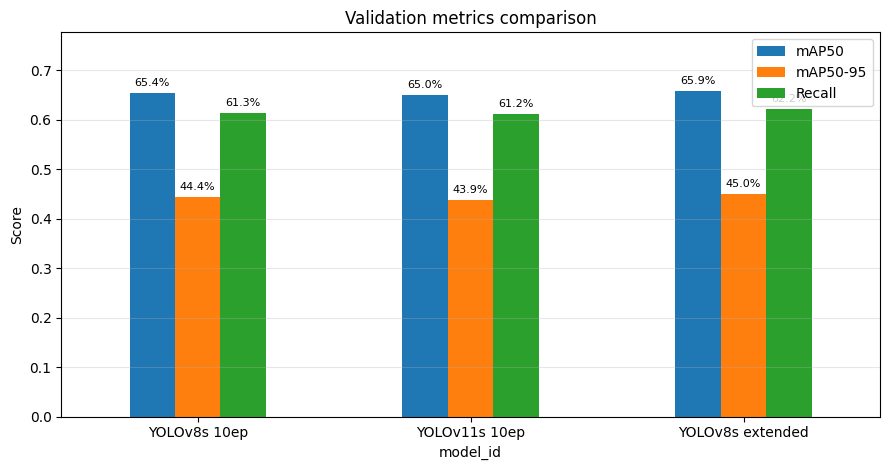

Saved: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_model/selected_model_overall_comparison.png


In [12]:
def load_model_metric_row(model_id, path):
    payload = read_json(path, default={})
    dm = payload.get("dataset_metrics", {}) or {}
    rt = clean_runtime_metrics(payload.get("runtime_metrics", {}) or {})
    return {
        "model_id": model_id,
        "mAP50": to_float_or_none(dm.get("mAP50")),
        "mAP50_95": to_float_or_none(dm.get("mAP50_95")),
        "precision": to_float_or_none(dm.get("precision")),
        "recall": to_float_or_none(dm.get("recall")),
        "wall_time_fps": to_float_or_none(rt.get("wall_time_fps")),
        "source": safe_rel(path) if Path(path).exists() else "missing",
    }

comparison_rows = []

# Baseline 10ep: prefer recovered 10ep metrics if available.
YOLO8S_BASELINE_METRICS = YOLO8S_EXP_DIR / "metrics_10ep_baseline.json"
if not YOLO8S_BASELINE_METRICS.exists():
    YOLO8S_BASELINE_METRICS = YOLO8S_EXP_DIR / "metrics.json"
comparison_rows.append(load_model_metric_row("YOLOv8s 10ep", YOLO8S_BASELINE_METRICS))
comparison_rows.append(load_model_metric_row("YOLOv11s 10ep", YOLO11S_EXP_DIR / "metrics.json"))

# Extended clean from current metrics_payload. This should be notebook 05 source-of-truth metrics.
dm = metrics_payload.get("dataset_metrics", {}) or {}
rt = metrics_payload.get("runtime_metrics", {}) or {}
comparison_rows.append({
    "model_id": "YOLOv8s extended",
    "mAP50": to_float_or_none(dm.get("mAP50")),
    "mAP50_95": to_float_or_none(dm.get("mAP50_95")),
    "precision": to_float_or_none(dm.get("precision")),
    "recall": to_float_or_none(dm.get("recall")),
    "wall_time_fps": to_float_or_none(rt.get("wall_time_fps")),
    "source": safe_rel(EXTENDED_METRICS_SOURCE),
})

comparison_df = pd.DataFrame(comparison_rows)
COMPARISON_CSV = REPORT_DIR / "selected_model_overall_comparison.csv"
comparison_df.to_csv(COMPARISON_CSV, index=False)

display(comparison_df)
print("Saved:", COMPARISON_CSV)

plot_df = comparison_df.dropna(subset=["mAP50", "mAP50_95", "recall"], how="all").copy()
if not plot_df.empty:
    chart_path = REPORT_DIR / "selected_model_overall_comparison.png"
    ax = plot_df.set_index("model_id")[["mAP50", "mAP50_95", "recall"]].plot(kind="bar", figsize=(9, 4.8))
    ax.set_title("Validation metrics comparison")
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(["mAP50", "mAP50-95", "Recall"])
    plt.xticks(rotation=0)
    annotate_bars(ax, formatter=format_score_bar_label, fontsize=8)
    plt.tight_layout()
    plt.savefig(chart_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", chart_path)
else:
    print("No comparison chart because metrics are missing.")


## 12. Report charts for selected model


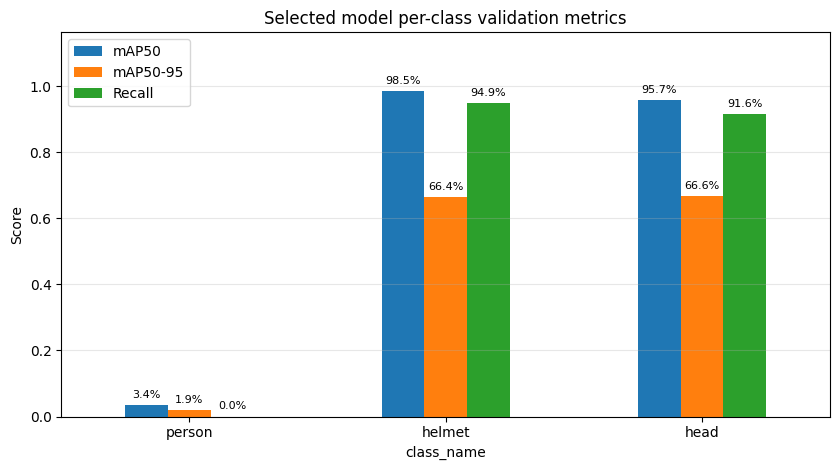

Saved: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_model/selected_model_per_class_map50.png


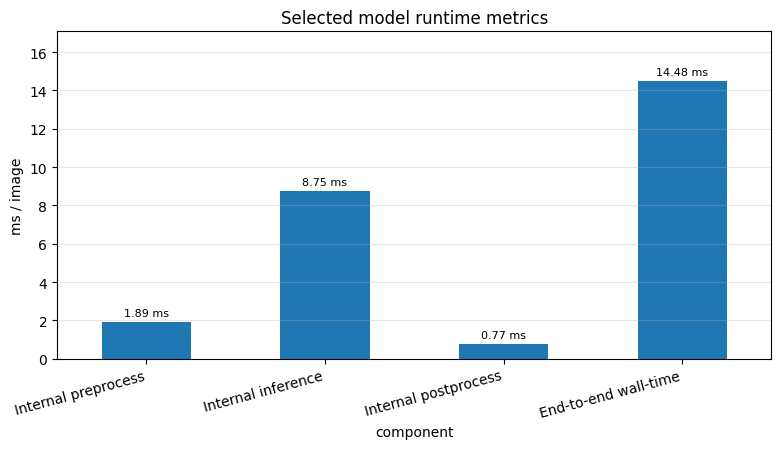

Saved: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_model/selected_model_runtime_breakdown.png
Detection count chart skipped because detections_df is empty.
Risk signal chart skipped because risk_df is empty.


In [13]:
# Per-class metric chart
per_class_plot_df = per_class_df.copy()
for col in ["precision", "recall", "mAP50", "mAP50_95"]:
    per_class_plot_df[col] = per_class_plot_df[col].apply(to_float_or_none)

if not per_class_plot_df.empty and per_class_plot_df[["mAP50", "mAP50_95", "recall"]].notna().any().any():
    chart_path = REPORT_DIR / "selected_model_per_class_map50.png"
    ax = per_class_plot_df.set_index("class_name")[["mAP50", "mAP50_95", "recall"]].plot(kind="bar", figsize=(8.5, 4.8))
    ax.set_title("Selected model per-class validation metrics")
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(["mAP50", "mAP50-95", "Recall"])
    plt.xticks(rotation=0)
    annotate_bars(ax, formatter=format_score_bar_label, fontsize=8)
    plt.tight_layout()
    plt.savefig(chart_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", chart_path)
else:
    print("Per-class metric chart skipped because per-class metrics are missing.")

# Runtime breakdown chart
rt = metrics_payload.get("runtime_metrics", {}) or {}
runtime_items = {
    "Internal preprocess": to_float_or_none(rt.get("ultralytics_preprocess_ms_per_image")),
    "Internal inference": to_float_or_none(rt.get("ultralytics_inference_ms_per_image")),
    "Internal postprocess": to_float_or_none(rt.get("ultralytics_postprocess_ms_per_image")),
    "End-to-end wall-time": to_float_or_none(rt.get("wall_time_ms_per_image")),
}
runtime_plot_df = pd.DataFrame(
    [{"component": key, "ms_per_image": value} for key, value in runtime_items.items() if value is not None]
)

if not runtime_plot_df.empty:
    chart_path = REPORT_DIR / "selected_model_runtime_breakdown.png"
    ax = runtime_plot_df.set_index("component")["ms_per_image"].plot(kind="bar", figsize=(8, 4.6))
    ax.set_title("Selected model runtime metrics")
    ax.set_ylabel("ms / image")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=15, ha="right")
    annotate_bars(ax, formatter=format_ms_label, fontsize=8)
    plt.tight_layout()
    plt.savefig(chart_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", chart_path)
else:
    print("Runtime chart skipped because runtime metrics are missing.")

# Detection count chart
if "detections_df" in globals() and not detections_df.empty:
    count_path = REPORT_DIR / "selected_model_detection_counts.png"
    class_counts = detections_df["class_name"].value_counts().sort_values(ascending=False)
    ax = class_counts.plot(kind="bar", figsize=(8, 4.5))
    ax.set_title("Selected model detections on report samples")
    ax.set_xlabel("Class")
    ax.set_ylabel("Detection count")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    annotate_bars(ax, formatter=format_count_label, fontsize=8)
    plt.tight_layout()
    plt.savefig(count_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", count_path)
else:
    print("Detection count chart skipped because detections_df is empty.")

# Risk signal image-count chart
if "risk_df" in globals() and not risk_df.empty:
    risk_count_path = REPORT_DIR / "selected_model_risk_signal_counts.png"
    cols = [c for c in ["person_detected", "helmet_detected", "head_or_no_helmet_detected"] if c in risk_df.columns]
    if cols:
        signal_counts = risk_df[cols].sum().sort_values(ascending=False)
        ax = signal_counts.plot(kind="bar", figsize=(8, 4.6))
        ax.set_title("Sample images with each selected-model risk signal")
        ax.set_xlabel("Risk signal")
        ax.set_ylabel("Image count")
        ax.grid(axis="y", alpha=0.3)
        plt.xticks(rotation=25, ha="right")
        annotate_bars(ax, formatter=format_count_label, fontsize=8)
        plt.tight_layout()
        plt.savefig(risk_count_path, dpi=220, bbox_inches="tight")
        plt.show()
        print("Saved:", risk_count_path)
    else:
        print("Risk signal chart skipped because expected signal columns are missing.")
else:
    print("Risk signal chart skipped because risk_df is empty.")


## 12b. Report-ready tables and trade-off charts

Các bảng/chart dưới đây được format để copy thẳng vào report/slide. Mục tiêu là làm rõ:

- YOLOv8s extended chỉ cải thiện nhẹ nhưng vẫn giữ realtime FPS.
- Checkpoint được chọn là PPE detector, mạnh ở helmet/head.
- Person class yếu nên không dùng checkpoint này làm person detector chính cho danger-zone logic.


,Model,mAP50,mAP50-95,Precision,Recall,Wall-time FPS,Decision
0,YOLOv8s 10ep,65.40%,44.43%,96.22%,61.31%,70.81,Baseline candidate
1,YOLOv11s 10ep,65.04%,43.88%,96.17%,61.16%,66.59,Candidate
2,YOLOv8s extended,65.86%,45.00%,96.10%,62.16%,69.07,Selected PPE checkpoint


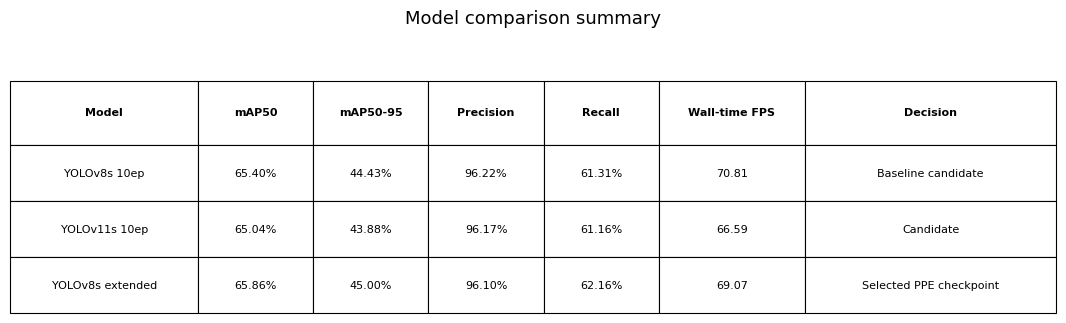

Saved: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_model/report_table_model_comparison.png


,Metric,YOLOv8s 10ep,YOLOv8s extended,Delta,Interpretation
0,mAP50,65.40%,65.86%,+0.46 pp,Minor change
1,mAP50-95,44.43%,45.00%,+0.57 pp,Slight quality improvement
2,Precision,96.22%,96.10%,-0.12 pp,Minor change
3,Recall,61.31%,62.16%,+0.85 pp,Slight quality improvement
4,Wall-time FPS,70.81,69.07,-1.74,Still realtime; acceptable FPS trade-off


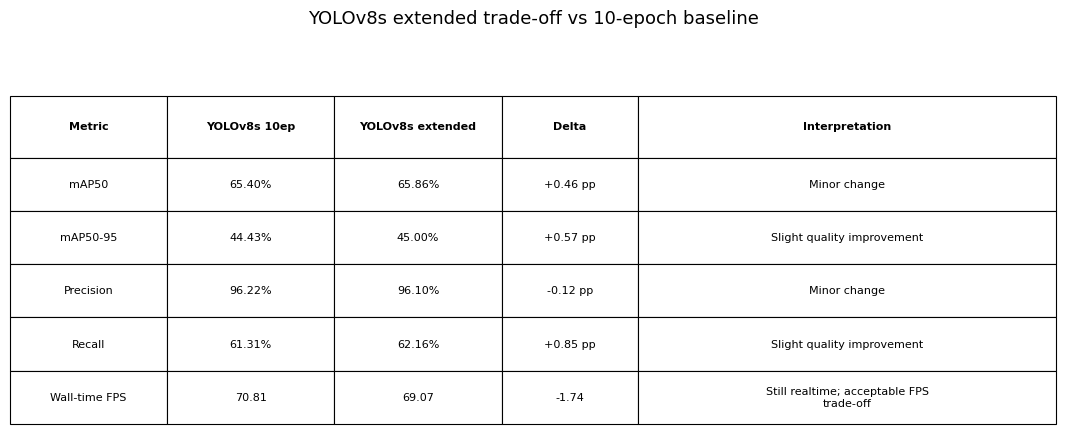

Saved: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_model/report_table_extended_tradeoff.png


,Class,Project signal,Precision,Recall,mAP50,mAP50-95,Report interpretation
0,person,person_detected,100.00%,0.00%,3.36%,1.93%,Weak for person; use separate person detector ...
1,helmet,helmet_detected,95.58%,94.94%,98.51%,66.42%,Strong PPE signal for risk engine
2,head,head_or_no_helmet_detected,92.71%,91.55%,95.72%,66.64%,Strong PPE signal for risk engine


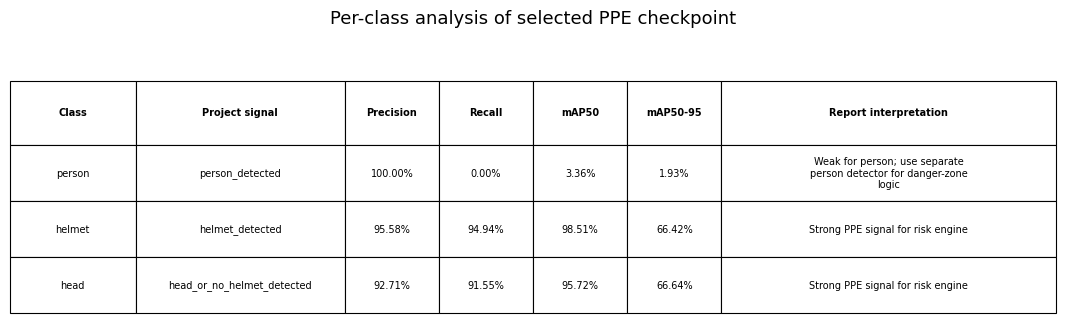

Saved: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_model/report_table_per_class_analysis.png


In [14]:
# ===== Report-ready tables =====
# These tables are easier to paste into the final report than raw notebook outputs.

def percent_or_na(value, digits=2):
    f = to_float_or_none(value)
    if f is None:
        return "N/A"
    return f"{f * 100:.{digits}f}%"

def number_or_na(value, digits=2):
    f = to_float_or_none(value)
    if f is None:
        return "N/A"
    return f"{f:.{digits}f}"

def save_dataframe_as_image(
    df: pd.DataFrame,
    path: Path,
    title: str = "",
    font_size: int = 8,
    wrap_widths: dict | None = None,
    col_widths: list | None = None,
):
    """Save a dataframe as a report-friendly PNG table with wrapped text."""
    path.parent.mkdir(parents=True, exist_ok=True)

    wrap_widths = wrap_widths or {}
    display_df = df.copy().astype(str)

    for col in display_df.columns:
        if col in wrap_widths:
            display_df[col] = display_df[col].apply(lambda x: wrap_cell_text(x, wrap_widths[col]))
        elif "Interpretation" in col or "interpretation" in col or "Decision" in col:
            display_df[col] = display_df[col].apply(lambda x: wrap_cell_text(x, 26))
        elif "signal" in col.lower():
            display_df[col] = display_df[col].apply(lambda x: wrap_cell_text(x, 22))

    row_count = max(len(display_df), 1)
    col_count = max(len(display_df.columns), 1)
    fig_w = max(13.5, col_count * 1.85)
    fig_h = max(2.8, row_count * 0.72 + 1.35)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    if title:
        ax.set_title(title, fontsize=13, pad=14)

    if col_widths is None:
        col_widths = [1 / col_count] * col_count

    table = ax.table(
        cellText=display_df.values,
        colLabels=display_df.columns,
        loc="center",
        cellLoc="center",
        colWidths=col_widths,
        bbox=[0, 0, 1, 0.86] if title else [0, 0, 1, 1],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1, 1.6)

    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(0.8)
        if row == 0:
            cell.set_text_props(weight="bold", va="center")
            cell.set_height(cell.get_height() * 1.15)
        else:
            cell.set_text_props(va="center")

    plt.savefig(path, dpi=240, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

# 1) Model comparison table
report_comparison_df = comparison_df.copy()

decision_map = {
    "YOLOv8s 10ep": "Baseline candidate",
    "YOLOv11s 10ep": "Candidate",
    "YOLOv8s extended": "Selected PPE checkpoint",
}

report_comparison_table = pd.DataFrame({
    "Model": report_comparison_df["model_id"],
    "mAP50": report_comparison_df["mAP50"].apply(percent_or_na),
    "mAP50-95": report_comparison_df["mAP50_95"].apply(percent_or_na),
    "Precision": report_comparison_df["precision"].apply(percent_or_na),
    "Recall": report_comparison_df["recall"].apply(percent_or_na),
    "Wall-time FPS": report_comparison_df["wall_time_fps"].apply(number_or_na),
    "Decision": report_comparison_df["model_id"].map(decision_map).fillna("Reference"),
})

MODEL_COMPARISON_TABLE_CSV = REPORT_DIR / "report_table_model_comparison.csv"
MODEL_COMPARISON_TABLE_PNG = REPORT_DIR / "report_table_model_comparison.png"
report_comparison_table.to_csv(MODEL_COMPARISON_TABLE_CSV, index=False)
display(report_comparison_table)
save_dataframe_as_image(
    report_comparison_table,
    MODEL_COMPARISON_TABLE_PNG,
    "Model comparison summary",
    font_size=8,
    wrap_widths={"Decision": 24},
    col_widths=[0.18, 0.11, 0.11, 0.11, 0.11, 0.14, 0.24],
)

# 2) Trade-off table: YOLOv8s 10ep vs YOLOv8s extended
def get_model_row(df, model_name):
    rows = df[df["model_id"] == model_name]
    if rows.empty:
        return None
    return rows.iloc[0]

base_row = get_model_row(comparison_df, "YOLOv8s 10ep")
extended_row = get_model_row(comparison_df, "YOLOv8s extended")

tradeoff_rows = []
if base_row is not None and extended_row is not None:
    tradeoff_specs = [
        ("mAP50", "mAP50", True),
        ("mAP50-95", "mAP50_95", True),
        ("Precision", "precision", True),
        ("Recall", "recall", True),
        ("Wall-time FPS", "wall_time_fps", False),
    ]

    for label, col, is_score in tradeoff_specs:
        base_val = to_float_or_none(base_row.get(col))
        ext_val = to_float_or_none(extended_row.get(col))

        if base_val is None or ext_val is None:
            base_display = "N/A"
            ext_display = "N/A"
            delta_display = "N/A"
            interpretation = "Missing metric"
        else:
            delta = ext_val - base_val
            if is_score:
                base_display = f"{base_val * 100:.2f}%"
                ext_display = f"{ext_val * 100:.2f}%"
                delta_display = f"{delta * 100:+.2f} pp"
            else:
                base_display = f"{base_val:.2f}"
                ext_display = f"{ext_val:.2f}"
                delta_display = f"{delta:+.2f}"

            if col == "wall_time_fps":
                interpretation = "Still realtime; acceptable FPS trade-off" if ext_val >= 30 else "Below realtime target"
            elif col in {"mAP50_95", "recall"}:
                interpretation = "Slight quality improvement" if delta > 0 else "No improvement"
            else:
                interpretation = "Minor change"

        tradeoff_rows.append({
            "Metric": label,
            "YOLOv8s 10ep": base_display,
            "YOLOv8s extended": ext_display,
            "Delta": delta_display,
            "Interpretation": interpretation,
        })

tradeoff_table = pd.DataFrame(tradeoff_rows)
TRADEOFF_TABLE_CSV = REPORT_DIR / "report_table_extended_tradeoff.csv"
TRADEOFF_TABLE_PNG = REPORT_DIR / "report_table_extended_tradeoff.png"
tradeoff_table.to_csv(TRADEOFF_TABLE_CSV, index=False)
display(tradeoff_table)
save_dataframe_as_image(
    tradeoff_table,
    TRADEOFF_TABLE_PNG,
    "YOLOv8s extended trade-off vs 10-epoch baseline",
    font_size=8,
    wrap_widths={"Interpretation": 30},
    col_widths=[0.15, 0.16, 0.16, 0.13, 0.40],
)

# 3) Per-class report table
def class_interpretation(class_name, recall, map50):
    name = str(class_name).lower()
    recall_f = to_float_or_none(recall)
    map50_f = to_float_or_none(map50)

    if name == "person":
        return "Weak for person; use separate person detector for danger-zone logic"
    if name in {"helmet", "head"}:
        if (recall_f is not None and recall_f >= 0.8) and (map50_f is not None and map50_f >= 0.8):
            return "Strong PPE signal for risk engine"
        return "Usable PPE signal but should be smoothed temporally"
    return "Not part of MVP risk signals"

per_class_report_table = pd.DataFrame({
    "Class": per_class_df["class_name"],
    "Project signal": per_class_df["project_signal"],
    "Precision": per_class_df["precision"].apply(percent_or_na),
    "Recall": per_class_df["recall"].apply(percent_or_na),
    "mAP50": per_class_df["mAP50"].apply(percent_or_na),
    "mAP50-95": per_class_df["mAP50_95"].apply(percent_or_na),
    "Report interpretation": [
        class_interpretation(row["class_name"], row["recall"], row["mAP50"])
        for _, row in per_class_df.iterrows()
    ],
})

PER_CLASS_REPORT_TABLE_CSV = REPORT_DIR / "report_table_per_class_analysis.csv"
PER_CLASS_REPORT_TABLE_PNG = REPORT_DIR / "report_table_per_class_analysis.png"
per_class_report_table.to_csv(PER_CLASS_REPORT_TABLE_CSV, index=False)
display(per_class_report_table)
save_dataframe_as_image(
    per_class_report_table,
    PER_CLASS_REPORT_TABLE_PNG,
    "Per-class analysis of selected PPE checkpoint",
    font_size=7,
    wrap_widths={"Project signal": 20, "Report interpretation": 34},
    col_widths=[0.12, 0.20, 0.09, 0.09, 0.09, 0.09, 0.32],
)


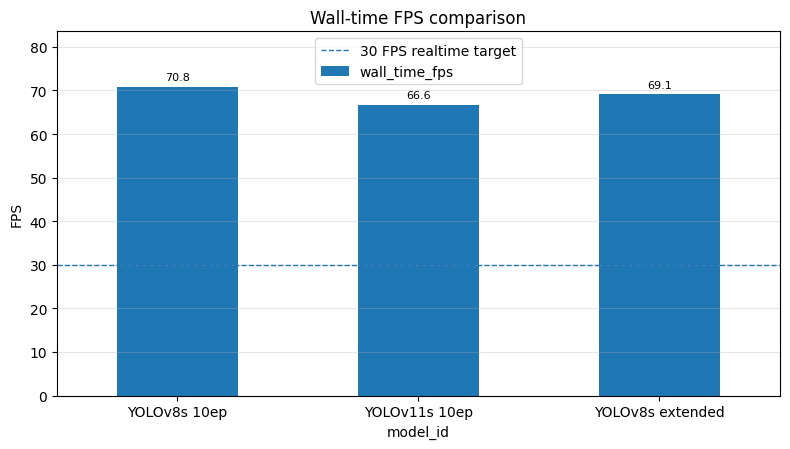

Saved: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_model/report_chart_fps_comparison.png


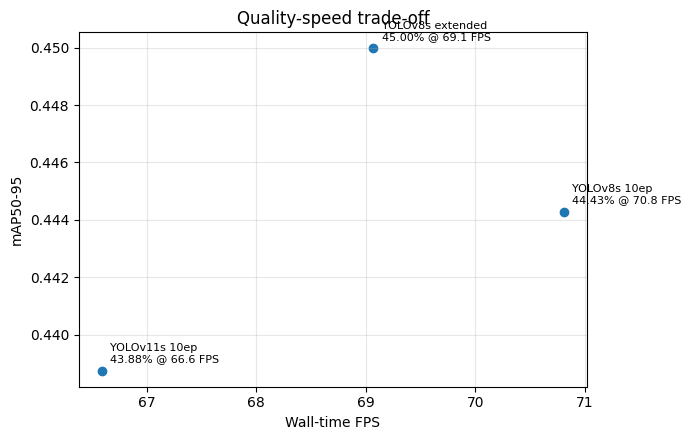

Saved: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_model/report_chart_quality_speed_tradeoff.png


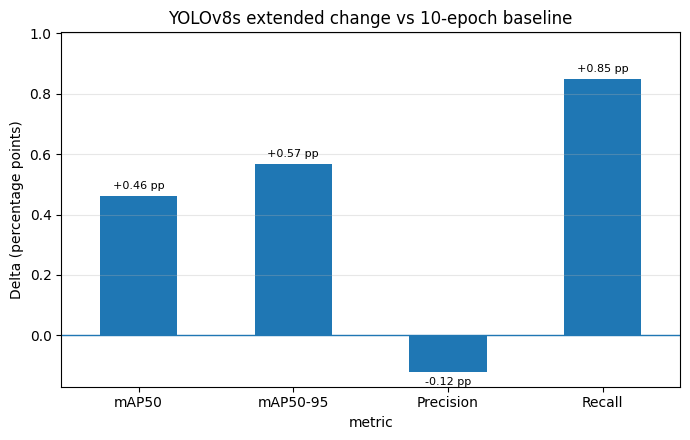

Saved: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_model/report_chart_extended_delta_vs_baseline.png


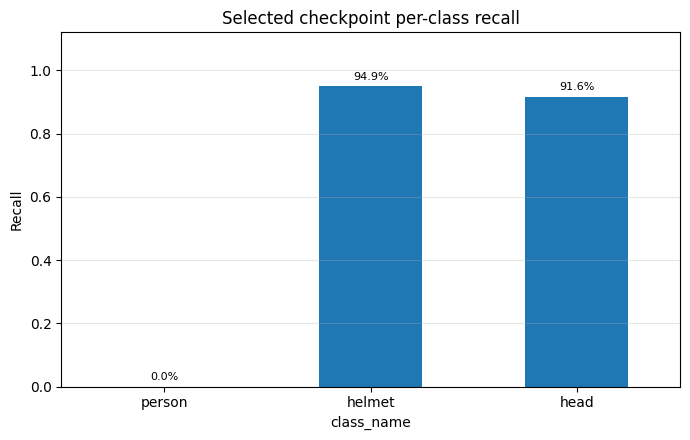

Saved: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_model/report_chart_per_class_recall.png
Extra report-ready outputs:
- experiments/report_artifacts/selected_model/report_table_model_comparison.csv | exists=True
- experiments/report_artifacts/selected_model/report_table_model_comparison.png | exists=True
- experiments/report_artifacts/selected_model/report_table_extended_tradeoff.csv | exists=True
- experiments/report_artifacts/selected_model/report_table_extended_tradeoff.png | exists=True
- experiments/report_artifacts/selected_model/report_table_per_class_analysis.csv | exists=True
- experiments/report_artifacts/selected_model/report_table_per_class_analysis.png | exists=True
- experiments/report_artifacts/selected_model/report_chart_fps_comparison.png | exists=True
- experiments/report_artifacts/selected_model/report_chart_quality_speed_tradeoff.png | exists=True
- experiments/report_artifacts/selected_model/report_chart_extended_delta_vs_ba

In [15]:
# ===== Report-ready charts =====

# 1) FPS comparison chart
fps_plot_df = comparison_df.dropna(subset=["wall_time_fps"]).copy()
if not fps_plot_df.empty:
    chart_path = REPORT_DIR / "report_chart_fps_comparison.png"
    ax = fps_plot_df.set_index("model_id")["wall_time_fps"].plot(kind="bar", figsize=(8, 4.6))
    ax.set_title("Wall-time FPS comparison")
    ax.set_ylabel("FPS")
    ax.axhline(30, linestyle="--", linewidth=1, label="30 FPS realtime target")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    plt.xticks(rotation=0)
    annotate_bars(ax, formatter=format_fps_label, fontsize=8)
    plt.tight_layout()
    plt.savefig(chart_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", chart_path)

# 2) Quality-speed scatter chart
qs_plot_df = comparison_df.dropna(subset=["mAP50_95", "wall_time_fps"]).copy()
if not qs_plot_df.empty:
    chart_path = REPORT_DIR / "report_chart_quality_speed_tradeoff.png"
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.scatter(qs_plot_df["wall_time_fps"], qs_plot_df["mAP50_95"])
    for _, row in qs_plot_df.iterrows():
        ax.annotate(
            f'{row["model_id"]}\n{row["mAP50_95"]*100:.2f}% @ {row["wall_time_fps"]:.1f} FPS',
            (row["wall_time_fps"], row["mAP50_95"]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=8,
        )
    ax.set_title("Quality-speed trade-off")
    ax.set_xlabel("Wall-time FPS")
    ax.set_ylabel("mAP50-95")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(chart_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", chart_path)

# 3) YOLOv8s extended delta chart vs baseline
if base_row is not None and extended_row is not None:
    delta_chart_rows = []
    for label, col in [
        ("mAP50", "mAP50"),
        ("mAP50-95", "mAP50_95"),
        ("Precision", "precision"),
        ("Recall", "recall"),
    ]:
        base_val = to_float_or_none(base_row.get(col))
        ext_val = to_float_or_none(extended_row.get(col))
        if base_val is not None and ext_val is not None:
            delta_chart_rows.append({"metric": label, "delta_pp": (ext_val - base_val) * 100})

    delta_df = pd.DataFrame(delta_chart_rows)
    if not delta_df.empty:
        chart_path = REPORT_DIR / "report_chart_extended_delta_vs_baseline.png"
        ax = delta_df.set_index("metric")["delta_pp"].plot(kind="bar", figsize=(7, 4.5))
        ax.set_title("YOLOv8s extended change vs 10-epoch baseline")
        ax.set_ylabel("Delta (percentage points)")
        ax.axhline(0, linewidth=1)
        ax.grid(axis="y", alpha=0.3)
        plt.xticks(rotation=0)
        annotate_bars(ax, formatter=format_delta_pp_label, fontsize=8)
        plt.tight_layout()
        plt.savefig(chart_path, dpi=220, bbox_inches="tight")
        plt.show()
        print("Saved:", chart_path)

# 4) Per-class recall chart, useful for limitation discussion
if not per_class_plot_df.empty and per_class_plot_df["recall"].notna().any():
    chart_path = REPORT_DIR / "report_chart_per_class_recall.png"
    ax = per_class_plot_df.set_index("class_name")["recall"].plot(kind="bar", figsize=(7, 4.5))
    ax.set_title("Selected checkpoint per-class recall")
    ax.set_ylabel("Recall")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    annotate_bars(ax, formatter=format_score_bar_label, fontsize=8)
    plt.tight_layout()
    plt.savefig(chart_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", chart_path)

print("Extra report-ready outputs:")
for path in [
    MODEL_COMPARISON_TABLE_CSV,
    MODEL_COMPARISON_TABLE_PNG,
    TRADEOFF_TABLE_CSV,
    TRADEOFF_TABLE_PNG,
    PER_CLASS_REPORT_TABLE_CSV,
    PER_CLASS_REPORT_TABLE_PNG,
    REPORT_DIR / "report_chart_fps_comparison.png",
    REPORT_DIR / "report_chart_quality_speed_tradeoff.png",
    REPORT_DIR / "report_chart_extended_delta_vs_baseline.png",
    REPORT_DIR / "report_chart_per_class_recall.png",
]:
    print(f"- {safe_rel(path)} | exists={Path(path).exists()}")


## 13. Copy official training/validation artifacts to report folder


In [16]:
# Copy common artifacts with stable report-friendly names.
artifact_candidates = []

train_dir = resolve_path_from_metrics(metrics_payload, "artifacts", "train_dir")
val_dir = resolve_path_from_metrics(metrics_payload, "artifacts", "val_dir")

# If metrics lacks paths, infer from best.pt.
if train_dir is None and BEST_PT is not None:
    train_dir = BEST_PT.parents[1]  # .../runs/train_xxx
if val_dir is None:
    val_candidates = sorted(YOLO8S_EXP_DIR.glob("runs/val_*selected*")) + sorted(YOLO8S_EXP_DIR.glob("runs/val_selected_report_artifacts"))
    if val_candidates:
        val_dir = sorted(val_candidates, key=lambda p: p.stat().st_mtime)[-1]

print("train_dir:", train_dir)
print("val_dir:", val_dir)

copy_plan = [
    (train_dir / "results.png" if train_dir else None, REPORT_DIR / "selected_model_training_curves.png"),
    (train_dir / "labels.jpg" if train_dir else None, REPORT_DIR / "selected_model_dataset_labels.jpg"),
    (train_dir / "labels_correlogram.jpg" if train_dir else None, REPORT_DIR / "selected_model_labels_correlogram.jpg"),
    (val_dir / "confusion_matrix.png" if val_dir else None, REPORT_DIR / "selected_model_confusion_matrix.png"),
    (val_dir / "confusion_matrix_normalized.png" if val_dir else None, REPORT_DIR / "selected_model_confusion_matrix_normalized.png"),
    (val_dir / "PR_curve.png" if val_dir else None, REPORT_DIR / "selected_model_pr_curve.png"),
    (val_dir / "F1_curve.png" if val_dir else None, REPORT_DIR / "selected_model_f1_curve.png"),
    (val_dir / "P_curve.png" if val_dir else None, REPORT_DIR / "selected_model_precision_curve.png"),
    (val_dir / "R_curve.png" if val_dir else None, REPORT_DIR / "selected_model_recall_curve.png"),
]

copied_artifacts = []
for src, dst in copy_plan:
    copied = copy_if_exists(src, dst) if src else None
    if copied:
        copied_artifacts.append(copied)

# Copy a small set of annotated samples to report folder.
if visual_prediction_dir and Path(visual_prediction_dir).exists():
    sample_report_dir = REPORT_DIR / "selected_model_annotated_samples"
    sample_report_dir.mkdir(parents=True, exist_ok=True)
    for p in collect_images_from_dir(Path(visual_prediction_dir), limit=12):
        dst = sample_report_dir / p.name
        shutil.copy2(p, dst)
        copied_artifacts.append(dst)
    print("Copied annotated samples to:", sample_report_dir)
    show_image_grid(collect_images_from_dir(sample_report_dir, limit=9), title="Report annotated samples", max_images=9, cols=3)

print("Copied artifact count:", len(copied_artifacts))


train_dir: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/yolo8s_ppe/runs/train_50ep_selected_20260708_173557
val_dir: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/yolo8s_ppe/runs/val_50ep_selected_20260708_173557_recovered
Copied: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/yolo8s_ppe/runs/train_50ep_selected_20260708_173557/results.png -> /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_model/selected_model_training_curves.png
Copied: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/yolo8s_ppe/runs/train_50ep_selected_20260708_173557/labels.jpg -> /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_model/selected_model_dataset_labels.jpg
Copied: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/yolo8s_ppe/runs/val_50ep_selected_20260708_173557_recovered/confusion_matrix.png -> /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_mode

## 14. Save cleaned metrics and final report summary


In [17]:
metrics_payload["model_id"] = "yolo8s_ppe_extended_report_clean"
metrics_payload["selected_checkpoint"] = safe_rel(BEST_PT)
metrics_payload["report_artifacts_dir"] = safe_rel(REPORT_DIR)
metrics_payload["metrics_source_before_cleaning"] = safe_rel(EXTENDED_METRICS_SOURCE)
metrics_payload["report_outputs"] = {
    "clean_metrics_json": safe_rel(CLEAN_METRICS_PATH),
    "overall_comparison_csv": safe_rel(COMPARISON_CSV),
    "per_class_metrics_csv": safe_rel(PER_CLASS_CSV),
    "detection_summary_csv": safe_rel(DETECTION_SUMMARY_CSV),
    "risk_signal_preview_csv": safe_rel(RISK_PREVIEW_CSV),
    "report_dir": safe_rel(REPORT_DIR),
}
metrics_payload["report_notes"] = {
    "how_to_use": (
        "Use this cleaned JSON and report_artifacts folder for report/slides/video. "
        "Keep notebook 04 as preliminary model selection; use notebook 06 for selected-checkpoint reporting."
    ),
    "runtime_note": (
        "Report wall-time FPS separately from Ultralytics inference-only speed to avoid mixing meanings."
    ),
    "system_note": (
        "YOLO is treated as perception layer. Final safety decision is produced by risk-signal extraction, "
        "zone logic, temporal smoothing, rule engine, and risk scoring."
    ),
}

write_json(CLEAN_METRICS_PATH, metrics_payload)

if SAVE_SELECTED_ALIAS:
    write_json(SELECTED_ALIAS_PATH, metrics_payload)

REPORT_MD = REPORT_DIR / "selected_model_report_artifacts.md"

# Determine limitation message from per-class metrics.
person_row = per_class_df[per_class_df["class_name"].astype(str).str.lower() == "person"]
person_warning = ""
if not person_row.empty:
    person_map50 = to_float_or_none(person_row.iloc[0].get("mAP50"))
    person_recall = to_float_or_none(person_row.iloc[0].get("recall"))
    if (person_map50 is not None and person_map50 < 0.2) or (person_recall is not None and person_recall < 0.2):
        person_warning = (
            "Class-level analysis shows that the selected PPE checkpoint is strong for helmet/head signals "
            "but weak for person detection. Therefore, the final system should use a separate person detector "
            "or COCO-pretrained person branch for danger-zone logic."
        )

summary_text = f"""# Selected Model Evaluation and Report Artifacts

## Selected checkpoint

- Checkpoint: `{safe_rel(BEST_PT)}`
- Source metrics: `{safe_rel(EXTENDED_METRICS_SOURCE)}`
- Clean metrics: `{safe_rel(CLEAN_METRICS_PATH)}`

## Overall validation metrics

| Metric | Value |
|---|---:|
| mAP50 | {fmt(metrics_payload.get("dataset_metrics", {}).get("mAP50"))} |
| mAP50-95 | {fmt(metrics_payload.get("dataset_metrics", {}).get("mAP50_95"))} |
| Precision | {fmt(metrics_payload.get("dataset_metrics", {}).get("precision"))} |
| Recall | {fmt(metrics_payload.get("dataset_metrics", {}).get("recall"))} |

## Runtime metrics

| Runtime metric | Value |
|---|---:|
| Wall-time FPS | {fmt(metrics_payload.get("runtime_metrics", {}).get("wall_time_fps"), 2)} |
| Wall-time ms/image | {fmt(metrics_payload.get("runtime_metrics", {}).get("wall_time_ms_per_image"), 2)} |
| Ultralytics preprocess ms/image | {fmt(metrics_payload.get("runtime_metrics", {}).get("ultralytics_preprocess_ms_per_image"), 2)} |
| Ultralytics inference ms/image | {fmt(metrics_payload.get("runtime_metrics", {}).get("ultralytics_inference_ms_per_image"), 2)} |
| Ultralytics postprocess ms/image | {fmt(metrics_payload.get("runtime_metrics", {}).get("ultralytics_postprocess_ms_per_image"), 2)} |

## Key report artifacts

- Overall comparison chart: `selected_model_overall_comparison.png`
- Per-class metric chart: `selected_model_per_class_map50.png`
- Runtime breakdown chart: `selected_model_runtime_breakdown.png`
- Detection count chart: `selected_model_detection_counts.png`
- Risk signal preview: `{safe_rel(RISK_PREVIEW_CSV)}`
- Per-class metrics CSV: `{safe_rel(PER_CLASS_CSV)}`
- Annotated samples folder: `selected_model_annotated_samples/`

## Recommended report narrative

The selected YOLOv8s extended checkpoint is used as the PPE perception layer. Extended training slightly improves validation quality compared with the initial 10-epoch candidate, while keeping runtime suitable for real-time system integration. However, frame-level detection is not the final decision. The final system converts model outputs into risk signals and combines them with zone logic, temporal smoothing, rule engine, and risk scoring before triggering alerts or IoT-simulator actions.

## Limitation

{person_warning if person_warning else "No severe person-class warning was automatically detected from available per-class metrics."}
"""

REPORT_MD.write_text(summary_text, encoding="utf-8")
print("Saved:", REPORT_MD)
display(Markdown(summary_text))


Saved: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/yolo8s_ppe/metrics_extended_report_clean.json
Saved: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/yolo8s_ppe/metrics_extended_selected.json
Saved: /content/drive/MyDrive/factory-safety-ai-cctv/experiments/report_artifacts/selected_model/selected_model_report_artifacts.md


# Selected Model Evaluation and Report Artifacts

## Selected checkpoint

- Checkpoint: `experiments/yolo8s_ppe/runs/train_50ep_selected_20260708_173557/weights/best.pt`
- Source metrics: `experiments/yolo8s_ppe/metrics_50ep_extended_20260708_173557.json`
- Clean metrics: `experiments/yolo8s_ppe/metrics_extended_report_clean.json`

## Overall validation metrics

| Metric | Value |
|---|---:|
| mAP50 | 0.6586 |
| mAP50-95 | 0.4500 |
| Precision | 0.9610 |
| Recall | 0.6216 |

## Runtime metrics

| Runtime metric | Value |
|---|---:|
| Wall-time FPS | 69.07 |
| Wall-time ms/image | 14.48 |
| Ultralytics preprocess ms/image | 1.89 |
| Ultralytics inference ms/image | 8.75 |
| Ultralytics postprocess ms/image | 0.77 |

## Key report artifacts

- Overall comparison chart: `selected_model_overall_comparison.png`
- Per-class metric chart: `selected_model_per_class_map50.png`
- Runtime breakdown chart: `selected_model_runtime_breakdown.png`
- Detection count chart: `selected_model_detection_counts.png`
- Risk signal preview: `experiments/report_artifacts/selected_model/selected_model_risk_signal_preview.csv`
- Per-class metrics CSV: `experiments/report_artifacts/selected_model/selected_model_per_class_metrics.csv`
- Annotated samples folder: `selected_model_annotated_samples/`

## Recommended report narrative

The selected YOLOv8s extended checkpoint is used as the PPE perception layer. Extended training slightly improves validation quality compared with the initial 10-epoch candidate, while keeping runtime suitable for real-time system integration. However, frame-level detection is not the final decision. The final system converts model outputs into risk signals and combines them with zone logic, temporal smoothing, rule engine, and risk scoring before triggering alerts or IoT-simulator actions.

## Limitation

Class-level analysis shows that the selected PPE checkpoint is strong for helmet/head signals but weak for person detection. Therefore, the final system should use a separate person detector or COCO-pretrained person branch for danger-zone logic.


## 15. Final checklist


In [18]:
print("Final files to use in report/slides:")
for path in [
    CLEAN_METRICS_PATH,
    SELECTED_ALIAS_PATH if SAVE_SELECTED_ALIAS else None,
    REPORT_DIR / "selected_model_overall_comparison.png",
    REPORT_DIR / "selected_model_per_class_map50.png",
    REPORT_DIR / "selected_model_runtime_breakdown.png",
    REPORT_DIR / "selected_model_detection_counts.png",
    REPORT_DIR / "selected_model_risk_signal_counts.png",
    REPORT_DIR / "selected_model_training_curves.png",
    REPORT_DIR / "selected_model_confusion_matrix_normalized.png",
    REPORT_DIR / "selected_model_dataset_labels.jpg",
    REPORT_DIR / "report_table_model_comparison.png",
    REPORT_DIR / "report_table_extended_tradeoff.png",
    REPORT_DIR / "report_table_per_class_analysis.png",
    REPORT_DIR / "report_chart_fps_comparison.png",
    REPORT_DIR / "report_chart_quality_speed_tradeoff.png",
    REPORT_DIR / "report_chart_extended_delta_vs_baseline.png",
    REPORT_DIR / "report_chart_per_class_recall.png",
    PER_CLASS_CSV,
    RISK_PREVIEW_CSV,
    REPORT_DIR / "selected_model_report_artifacts.md",
]:
    if path is None:
        continue
    print(f"- {safe_rel(path)} | exists={Path(path).exists()}")

print("\nNotebook 04 vẫn giữ vai trò model selection sơ bộ.")
print("Notebook 06 này dùng cho selected-checkpoint report artifacts.")


Final files to use in report/slides:
- experiments/yolo8s_ppe/metrics_extended_report_clean.json | exists=True
- experiments/yolo8s_ppe/metrics_extended_selected.json | exists=True
- experiments/report_artifacts/selected_model/selected_model_overall_comparison.png | exists=True
- experiments/report_artifacts/selected_model/selected_model_per_class_map50.png | exists=True
- experiments/report_artifacts/selected_model/selected_model_runtime_breakdown.png | exists=True
- experiments/report_artifacts/selected_model/selected_model_detection_counts.png | exists=False
- experiments/report_artifacts/selected_model/selected_model_risk_signal_counts.png | exists=False
- experiments/report_artifacts/selected_model/selected_model_training_curves.png | exists=True
- experiments/report_artifacts/selected_model/selected_model_confusion_matrix_normalized.png | exists=True
- experiments/report_artifacts/selected_model/selected_model_dataset_labels.jpg | exists=True
- experiments/report_artifacts/select